In [1]:
import pandas as pd
from RRAM import *
from tqdm import tqdm
import pickle

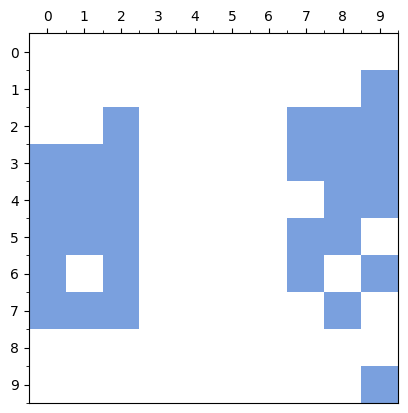

In [2]:

# df = pd.DataFrame(columns=['iteracion', 'Tiempo simulacion', 'Voltaje', 'Campo Eléctrico', 'Corriente', 'Temperatura',
#                   'Probabilidad de Generación', 'Probabilidad de Recombinación', 'Percolacion'])

# probs_r = pd.DataFrame(columns=['Paso Montecarlo', 'x', 'y', 'Aleatorio generado',
#                        'Probabilidad recombinación', 'Hay cambio'])

# probs_g = pd.DataFrame(columns=['Paso Montecarlo', 'x', 'y', 'Aleatorio generado',
#                        'Probabilidad generacion', 'Hay cambio'])

In [3]:
# comienzo la simulación montecaarlo

espesor_dispositivo = 5        # nm
Atom_size = 0.5                 # nm

eje_x = round(espesor_dispositivo / Atom_size)
eje_y = round(espesor_dispositivo / Atom_size)

num_trampas = 30

# TODO: Poner de alguna form más simple lños numeros para que al cambiar el grid se cambie todo solo
# Defino la región que quiero privilegiar y su peso
regiones_pesos = [
    ((2, eje_x-2, eje_y-3, eje_y), 50),             # First three columns with higher weight
    ((2, eje_x-2, 0, 3), 50),                       # First three columns with higher weight
]

# FIXME: Hay una zona donde nunca se ponen trampas --> Solucionado
actual_state = Generation.initial_state_priv(eje_x, eje_y, num_trampas, regiones_pesos)


RepresentateState(actual_state, 'Estado inicial')

NameError: name 'num_pasos' is not defined

In [ ]:

total_simulation_time = 1
num_pasos = 1000
paso_temporal = total_simulation_time / num_pasos

voltaje_final = 1

paso_guardar = 10

configuraciones_matriz = np.zeros((int((num_pasos / paso_guardar)), eje_x, eje_y))

# Configuraciones iniciales:
Temperatura = 350
Campo_Electrico = 0
voltaje = 0
simulation_time = 0
Corriente = 0

# Creo el vector de datos como una matriz de num_pasos filas y 4 columnas (x,y,probabilidad recombionacion, velocidad)
data = np.zeros((num_pasos, 4))

In [ ]:
# Creo el excel donde voy a sacar todos los datos
for k in tqdm(range(0, num_pasos)):

    # Guardo el estado anterior
    last_state = actual_state

    simulation_time = paso_temporal*k

    # Calculo la corriente
    voltaje += voltaje_final * paso_temporal

    # Obtengo la corrriente, antes decido cual usar comprobando si ha percolado o no
    # TODO: Revisar por quéme dice que ha percolado si no lo ha hecho
    if Percolation.is_path(actual_state):
        # Si ha percolado uso la corriente de percolación
        # Corriente = CurentSolver.OmhCurrent(Temperatura, Campo_Electrico)
        # print("Ha percolado")
        pass
    else:
        # Si no ha percolado uso la corriente de campo
        # TODO: REVISAR QUE LA CORRIENTE TIENE LAS UNIDADES CORRECTAS PORQUE NO CUADRAN VALORES.
        Corriente = CurentSolver.poole_frenkel(Temperatura, Campo_Electrico)/(1e-10)

    # Obtengo los valores del campo eléctrico y la temperatura
    Campo_Electrico = SimpleElectricField(voltaje, espesor_dispositivo*1e-9)
    Temperatura = Temperature_Joule(voltaje, Corriente, T_0=350)

    # Calculo la probabilidad de generación o recombinación para ello recorro toda la matriz
    for i in range(eje_x):
        for j in range(eje_y):
            if actual_state[i, j] == 0:
                # TODO: REVISAR PROBABILIDAD QUE A VECES SALE MAYOR DE 1
                # TODO: HACER UN REESCALADO DE LOS VALORES PARA EVITAR TENER QUE TRABAJAR CON NUMEROS TAN GRANDES
                prob_generacion = Generation.generation(paso_temporal, Campo_Electrico, Temperatura)
                random_number = np.random.rand()

                # probs_g.loc[k] = [k, i, j, random_number, prob_generacion, random_number < prob_generacion]

                if random_number < prob_generacion:
                    actual_state[i, j] = 1  # Generación

            else:
                # TODO: REVISAR PROBABILIDAD QUE A VECES SALE MAYOR DE 1
                # TODO: HACER UN REESCALADO DE LOS VALORES PARA EVITAR TENER QUE TRABAJAR CON NUMEROS TAN GRANDES
                prob_recombinacion = Recombination.recombination(paso_temporal, i, Campo_Electrico, Temperatura)
                data[k] = np.array([i, j, prob_recombinacion[0], prob_recombinacion[1]])
                # print(data[k])

                # genero un número aleatorio entre 0 y 1
                random_number = np.random.rand()
                # probs_r.loc[recom_index] = [k, i, j, random_number,
                #                             prob_recombinacion, random_number < prob_recombinacion]
                if random_number < prob_recombinacion[0]:
                    actual_state[i, j] = 0  # Recombinación
                # recom_index = recom_index + 1

    # if prob_generacion is None:
    #     # Guardo los datos en el excel
    #     df.loc[k] = [k, simulation_time, voltaje, Campo_Electrico, Corriente, Temperatura,
    #                  'no calculada no entra', prob_recombinacion, Percolation.is_path(actual_state)]

    # else:
    #     # Guardo los datos en el excel
    #     df.loc[k] = [k, simulation_time, voltaje, Campo_Electrico, Corriente, Temperatura,
    #                  prob_generacion, prob_recombinacion, Percolation.is_path(actual_state)]

    # Guardo el estado actual CADA paso_guardar PASOS MONTECARLO
    if k % paso_guardar == 0:
        configuraciones_matriz[int(k / paso_guardar) - 1] = actual_state

# Guardo los datos en un excel
# df.to_excel('Resultados_numericos/Resultados_Nuevos.xlsx', index=False)

# # Guardo los datos en un excel
# probs_g.to_excel('Resultados_numericos/probabilidades_generacion.xlsx', index=False)
# probs_r.to_excel('Resultados_numericos/probabilidades_Recombinacion.xlsx', index=False)

# Guardar la lista en un archivo
with open('Configuraciones.pkl', 'wb') as f:
    pickle.dump(configuraciones_matriz, f)

np.savetxt('Recombinacion_data.txt', data, header='x, y, probabilidad recombinacion, velocidad', comments='', delimiter=', ')

100%|██████████| 1000/1000 [00:02<00:00, 384.23it/s]


In [ ]:
# import pickle
# k = 30

# # Cargo los datos del archivo pickle
# with open('Configuraciones_medio.pkl', 'rb') as f:
#     data = pickle.load(f)

# RepresentatePoints(data[k], filename="Figuras/grafica_" + str(k) + ".png")
# print(data[k])